# 📊 Notebook 05 — Exploratory Data Analysis (EDA)

**Project:** Texas Injection Wells — Delaware Basin Analysis  
**Author:** Juan David Antolinez  
**Purpose:** Explore the final georeferenced dataset to answer key business questions about injection activity in the Delaware Basin (Texas) from 1997 to present.

---

### Business Questions
| # | Question | Chart Type |
|---|---|---|
| 1 | How has injection volume evolved over time? | Line chart |
| 2 | Which operators inject the most water? | Horizontal bar chart |
| 3 | How has the active well count changed month by month? | Line chart |
| 4 | Which county has the most injection activity? | Horizontal bar chart |
| 5 | How are wells geographically distributed by volume? | Spatial map |

### Dataset
- **Source:** `data/processed/delaware_injection_final.xlsx`
- **Records:** 175,838 monthly injection records
- **Wells:** 1,414 unique SWD wells
- **Period:** 1997 – 2025
- **Area:** Delaware Basin, Texas (7 counties)

## 1. Library Imports

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx

## 2. Project Paths

In [2]:
BASE_DIR   = Path.cwd().parent
DATA_FINAL = BASE_DIR / "data"       / "processed" / "delaware_injection_final.xlsx"
POLYGON    = BASE_DIR / "shapefiles" / "delaware_texas.shp"

## 3. Load Data

In [3]:
df = pd.read_excel(DATA_FINAL)

print(f"Dataset: {len(df):,} rows × {df.shape[1]} columns")
print(f"Unique wells:    {df['WellApi'].nunique():,}")
print(f"Unique operators:{df['OperatorName'].nunique():,}")
print(f"Counties:        {df['County'].nunique()}")
print(f"Date range:      {df['MonthYr'].min()} → {df['MonthYr'].max()}")

Dataset: 175,838 rows × 35 columns
Unique wells:    1,414
Unique operators:172
Counties:        7
Date range:      1996-05-01 00:00:00 → 2026-04-01 00:00:00


## 4. Question 1 — How Has Injection Volume Evolved Over Time?

Aggregate monthly injection volume across all wells to reveal long-term trends in the Delaware Basin.  
The chart reflects the Permian Basin shale boom, COVID-19 impact, and subsequent recovery.

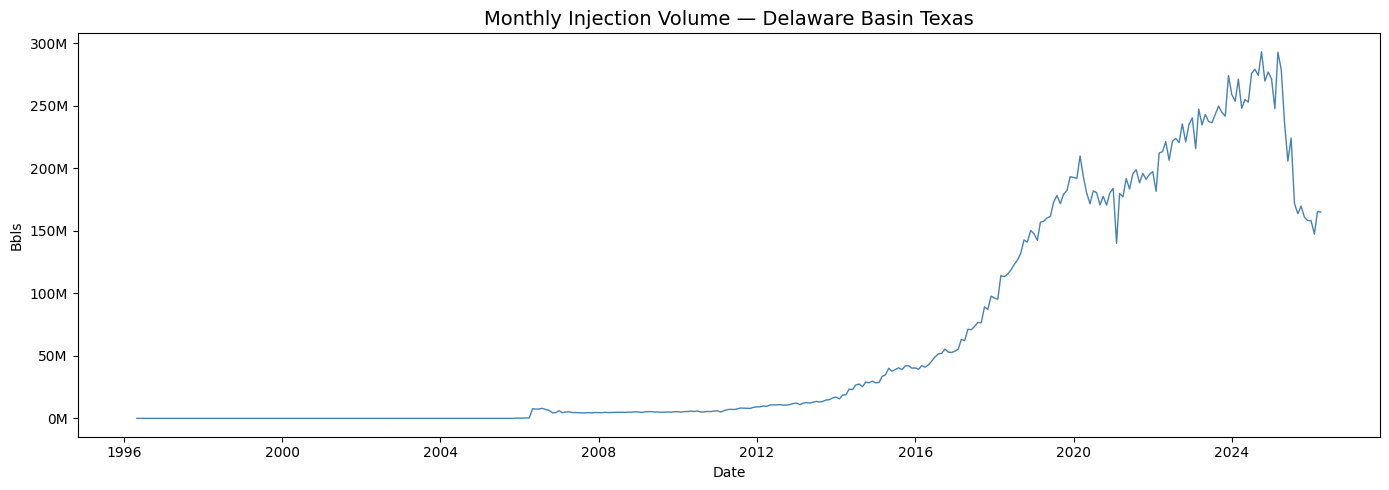

In [4]:
# Aggregate total monthly injection volume
df_bbl = df.groupby('MonthYr')['Bbls'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot('MonthYr', 'Bbls', data=df_bbl, color='steelblue', linewidth=1)
ax.set_title('Monthly Injection Volume — Delaware Basin Texas', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Bbls')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

## 5. Question 2 — Which Operators Inject the Most Water?

Rank operators by total lifetime injection volume and number of unique wells operated.

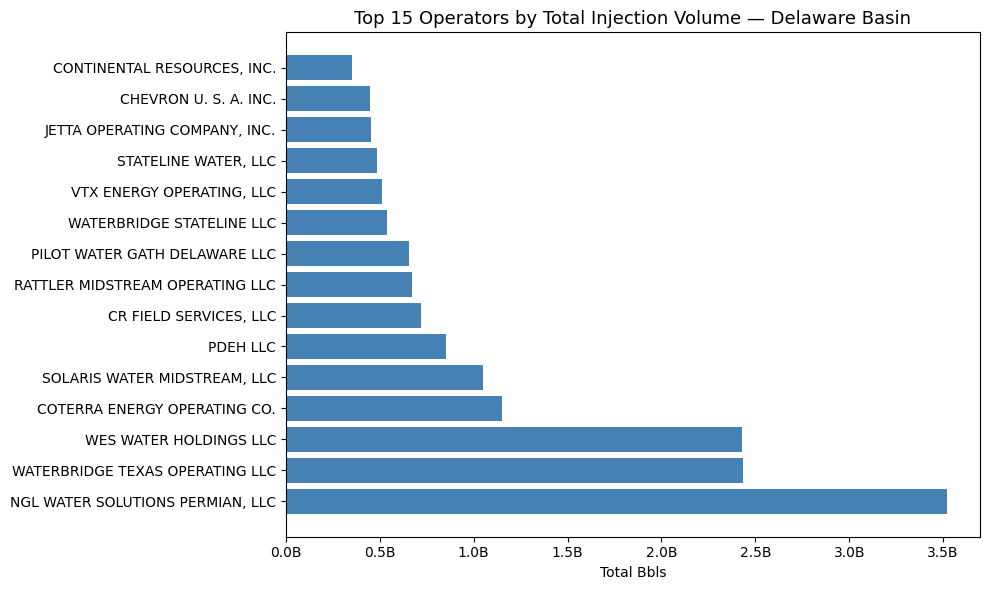

In [5]:
# Aggregate by operator
df_operators = df.groupby('OperatorName').agg(
    total_bbls   = ('Bbls',    'sum'),
    unique_wells = ('WellApi', 'nunique')
).reset_index().sort_values(by='total_bbls', ascending=False)

df_operators_top15 = df_operators.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh('OperatorName', 'total_bbls', data=df_operators_top15, color='steelblue')
ax.set_title('Top 15 Operators by Total Injection Volume — Delaware Basin', fontsize=13)
ax.set_xlabel('Total Bbls')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))
plt.tight_layout()
plt.show()

## 6. Question 3 — How Has the Active Well Count Changed Over Time?

Count unique active wells per month to track the growth and consolidation of injection infrastructure.  

> ⚠️ Note: The most recent months may show a decline due to **reporting lag** — operators have a grace period to submit H10 records to the RRC.

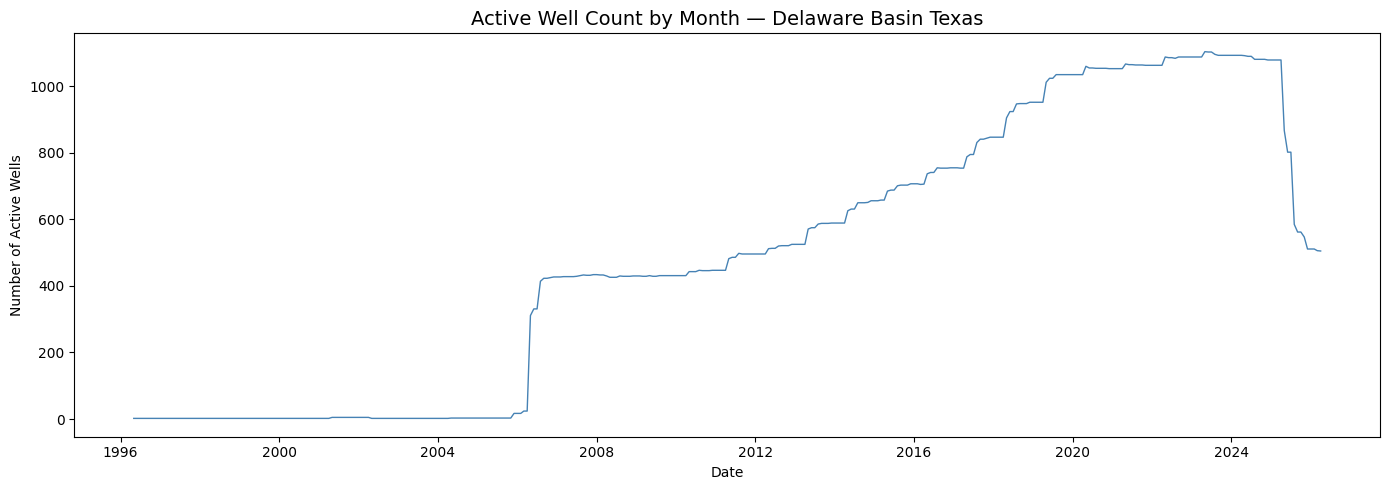

In [6]:
# Count unique wells per month
wells_by_month = df.groupby('MonthYr')['WellApi'].nunique().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot('MonthYr', 'WellApi', data=wells_by_month, color='steelblue', linewidth=1)
ax.set_title('Active Well Count by Month — Delaware Basin Texas', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Number of Active Wells')
plt.tight_layout()
plt.show()

## 7. Question 4 — Which County Has the Most Injection Activity?

Reeves County anchors the Delaware Basin — this chart confirms its dominance in well count.

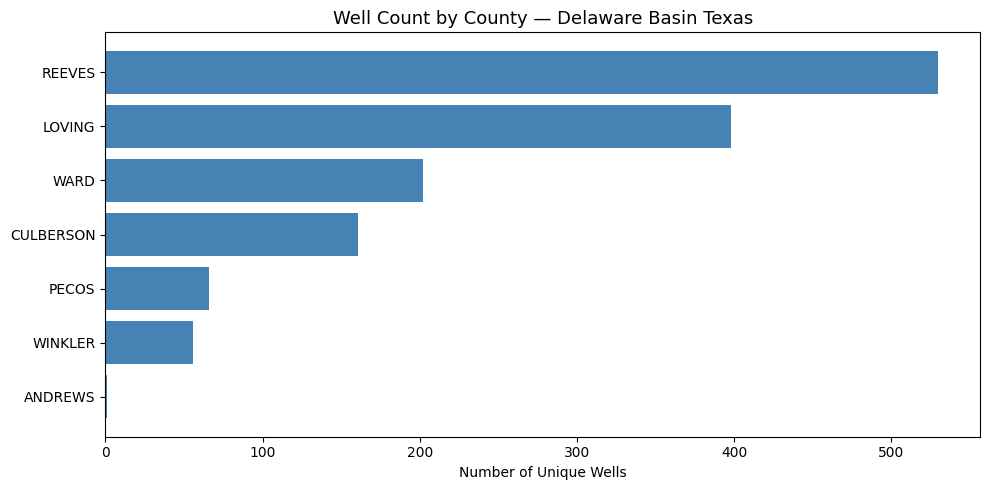

In [7]:
# Count unique wells per county
wells_by_county = (
    df.groupby('County')['WellApi']
    .nunique()
    .reset_index()
    .sort_values(by='WellApi', ascending=True)  # ascending for barh display
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh('County', 'WellApi', data=wells_by_county, color='steelblue')
ax.set_title('Well Count by County — Delaware Basin Texas', fontsize=13)
ax.set_xlabel('Number of Unique Wells')
plt.tight_layout()
plt.show()

## 8. Question 5 — Geographic Distribution of Wells by Injection Volume

Map each well as a point colored by its total lifetime injection volume.  
Darker red = higher volume. The Delaware Basin polygon boundary is overlaid for spatial context.

> **Color scale:** Yellow (low volume) → Orange → Red (high volume)

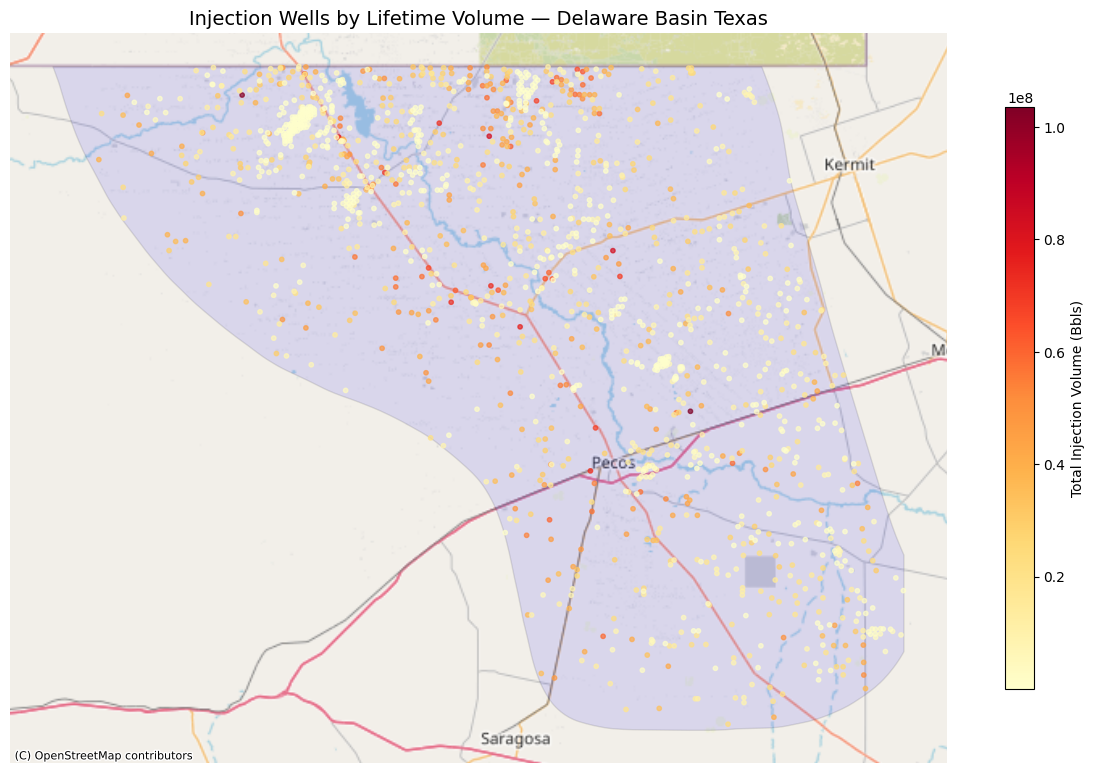

In [8]:
# Aggregate volume and coordinates per well
df_wells_volume = df.groupby('WellApi').agg(
    total_bbls = ('Bbls',       'sum'),
    latitude   = ('GisLatNad83',  'mean'),
    longitude  = ('GisLongNad83', 'mean'),
).reset_index().sort_values(by='total_bbls', ascending=False)

# Load Delaware Basin polygon
delaware_gdf = gpd.read_file(POLYGON)

# Convert wells to GeoDataFrame
wells_gdf = gpd.GeoDataFrame(
    df_wells_volume,
    geometry=gpd.points_from_xy(df_wells_volume['longitude'], df_wells_volume['latitude']),
    crs="EPSG:4326"
)

# Plot map
fig, ax = plt.subplots(figsize=(12, 10))

delaware_gdf.to_crs(epsg=3857).plot(
    ax=ax, alpha=0.1, color='blue', edgecolor='black', linewidth=1
)
wells_gdf.to_crs(epsg=3857).plot(
    ax=ax,
    column='total_bbls',
    cmap='YlOrRd',
    markersize=10,
    alpha=0.7,
    legend=True,
    legend_kwds={'label': 'Total Injection Volume (Bbls)', 'shrink': 0.6}
)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_title('Injection Wells by Lifetime Volume — Delaware Basin Texas', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()